### Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Data Preprocessing

In [2]:
training_set= tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 70295 files belonging to 38 classes.


In [3]:
validation_set= tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [4]:
training_set


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[139.25 128.25 126.25]
   [137.5  126.5  124.5 ]
   [140.   129.   127.  ]
   ...
   [168.75 156.75 156.75]
   [173.   161.   161.  ]
   [166.   154.   154.  ]]

  [[133.75 122.75 120.75]
   [122.25 111.25 109.25]
   [135.25 124.25 122.25]
   ...
   [157.75 145.75 145.75]
   [159.25 147.25 147.25]
   [164.75 152.75 152.75]]

  [[139.5  128.5  126.5 ]
   [160.5  149.5  147.5 ]
   [146.5  135.5  133.5 ]
   ...
   [178.25 166.25 166.25]
   [147.25 135.25 135.25]
   [164.   152.   152.  ]]

  ...

  [[144.75 126.75 124.75]
   [147.5  129.5  127.5 ]
   [136.75 118.75 116.75]
   ...
   [159.5  145.5  144.5 ]
   [146.25 132.25 131.25]
   [162.25 148.25 147.25]]

  [[162.5  144.5  142.5 ]
   [142.25 124.25 122.25]
   [145.25 127.25 125.25]
   ...
   [150.75 136.75 135.75]
   [153.25 139.25 138.25]
   [164.75 150.75 149.75]]

  [[148.   130.   128.  ]
   [127.75 109.75 107.75]
   [135.5  117.5  115.5 ]
   ...
   [169.5  155.5  154.5 ]
   [151.   137.   136.  ]
   [161.25 147.25 14

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

## Buliding Model

In [7]:
model= Sequential()

## Building Convolution Layer

In [8]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

C:\Users\ADITYA\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Dropout(0.25))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(units=1500,activation='relu'))

In [16]:
model.add(Dropout(0.4))

In [17]:
#output layer
model.add(Dense(units=38,activation='softmax'))

## Compiling Model

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 126, 126, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 63, 63, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [20]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1035s 469ms/step - accuracy: 0.3889 - loss: 2.1598 - val_accuracy: 0.8140 - val_loss: 0.5762
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 712s 324ms/step - accuracy: 0.8275 - loss: 0.5435 - val_accuracy: 0.8910 - val_loss: 0.3338
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 772s 351ms/step - accuracy: 0.9013 - loss: 0.3096 - val_accuracy: 0.9345 - val_loss: 0.1999
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 698s 318ms/step - accuracy: 0.9328 - loss: 0.1998 - val_accuracy: 0.9405 - val_loss: 0.1839
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 700s 319ms/step - accuracy: 0.9506 - loss: 0.1490 - val_accuracy: 0.9381 - val_loss: 0.1938
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 690s 314ms/step - accuracy: 0.9605 - loss: 0.1198 - val_accuracy: 0.9536 - val_loss: 0.1525
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 689s 314ms/step - accuracy: 0.9697 - loss: 0.0915 - val_accuracy: 0.9567 - val_loss: 0.1497
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 691s 314ms/step - a

## Model Evaluation

In [21]:
#Model Evaluation on training set
training_loss,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 211s 96ms/step - accuracy: 0.9878 - loss: 0.0360


In [22]:
print(training_loss,train_acc)

0.03405442461371422 0.9884913563728333


In [23]:
#Model Evaluation on Validation set
Val_loss,Val_acc=model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - accuracy: 0.9607 - loss: 0.1431


In [24]:
print(Val_loss,Val_acc)

0.14177390933036804 0.9603345990180969


## Saving Model

In [48]:
model.save("trained_model.keras")

In [26]:
training_history.history

{'accuracy': [0.5892453193664551,
  0.8508286476135254,
  0.9102354645729065,
  0.9387012124061584,
  0.9537377953529358,
  0.9631268382072449,
  0.9712497591972351,
  0.9761434197425842,
  0.9790881276130676,
  0.9819332957267761],
 'loss': [1.3948029279708862,
  0.46810945868492126,
  0.2792317569255829,
  0.18741841614246368,
  0.13999710977077484,
  0.11064804345369339,
  0.08657176792621613,
  0.07451882213354111,
  0.06394078582525253,
  0.05547032505273819],
 'val_accuracy': [0.8140223026275635,
  0.8909628987312317,
  0.9344980716705322,
  0.9404734969139099,
  0.9381402134895325,
  0.9535624980926514,
  0.9567493796348572,
  0.9492943286895752,
  0.9461074471473694,
  0.9603345990180969],
 'val_loss': [0.5762399435043335,
  0.33375704288482666,
  0.19992174208164215,
  0.1839391142129898,
  0.19376112520694733,
  0.15247927606105804,
  0.14974156022071838,
  0.16597352921962738,
  0.1872624158859253,
  0.14177390933036804]}

In [27]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

## Acuracy Visualization

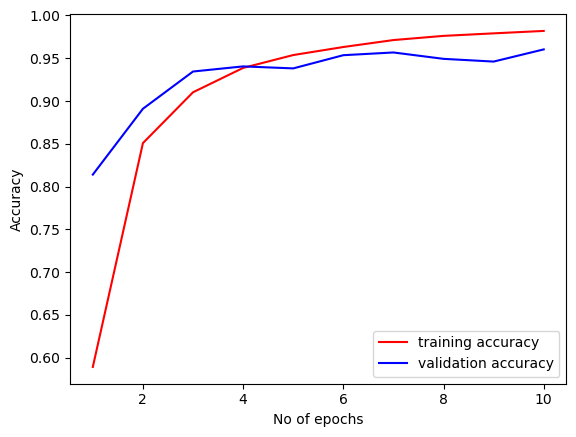

In [28]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='training accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='validation accuracy')
plt.xlabel("No of epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Some other metrics for model evaluation

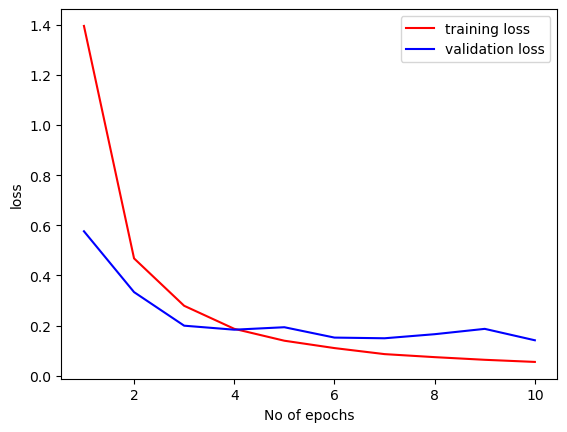

In [68]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['loss'],color='red',label='training loss')
plt.plot(epochs,training_history.history['val_loss'],color='blue',label='validation loss')
plt.xlabel("No of epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [52]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [53]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [54]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 47s 85ms/step


(array([[1.0000000e+00, 3.0523175e-09, 1.1232302e-12, ..., 3.3552570e-17,
         6.5013713e-15, 1.3550792e-15],
        [9.9999607e-01, 1.7682062e-07, 4.7530335e-10, ..., 4.1943855e-14,
         1.0393511e-12, 8.1442674e-12],
        [1.0000000e+00, 3.6947415e-13, 1.9119424e-14, ..., 1.2091463e-23,
         7.3767336e-19, 1.0681248e-19],
        ...,
        [9.7770170e-10, 2.3976231e-12, 9.6702379e-08, ..., 7.5962526e-12,
         2.1635955e-11, 9.9986911e-01],
        [2.8891460e-11, 7.1343154e-15, 6.3511793e-11, ..., 2.9421071e-12,
         1.5248290e-12, 1.0000000e+00],
        [5.8920695e-19, 5.0279972e-21, 2.1184039e-17, ..., 4.6457416e-20,
         5.4989359e-17, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [55]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [56]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [57]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [58]:
Y_true=tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [59]:
from sklearn.metrics import classification_report,confusion_matrix

In [60]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.94      0.95       504
                                 Apple___Black_rot       0.99      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.97      0.99      0.98       440
                                   Apple___healthy       0.95      0.95      0.95       502
                               Blueberry___healthy       0.92      0.97      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.91      1.00      0.95       421
                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.92      0.92       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.94      0.

In [61]:
cm=confusion_matrix(Y_true,predicted_categories)
cm

array([[476,   0,   0, ...,   0,   0,   0],
       [  3, 488,   0, ...,   0,   0,   0],
       [  0,   0, 434, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 486,   0,   0],
       [  0,   0,   0, ...,   0, 443,   1],
       [  0,   0,   0, ...,   0,   0, 480]], dtype=int64)

550/550 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step


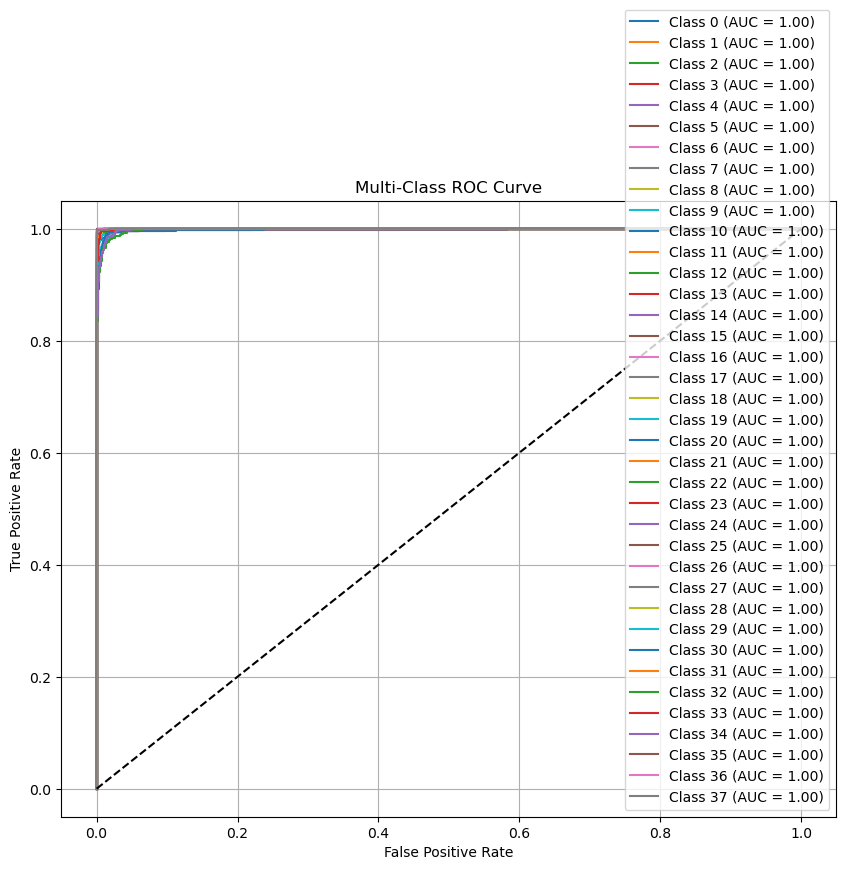

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# Step 1: Get predictions and true labels
y_pred = model.predict(test_set)

# Collect true labels
y_true = []
for _, labels in test_set:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Step 2: Ensure both are numpy arrays
# If y_true is one-hot, skip this line
# y_true = np.argmax(y_true, axis=1)

# Step 3: Compute ROC and AUC for each class
num_classes = y_pred.shape[1]
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 4: Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Confusion Matrix Visualization

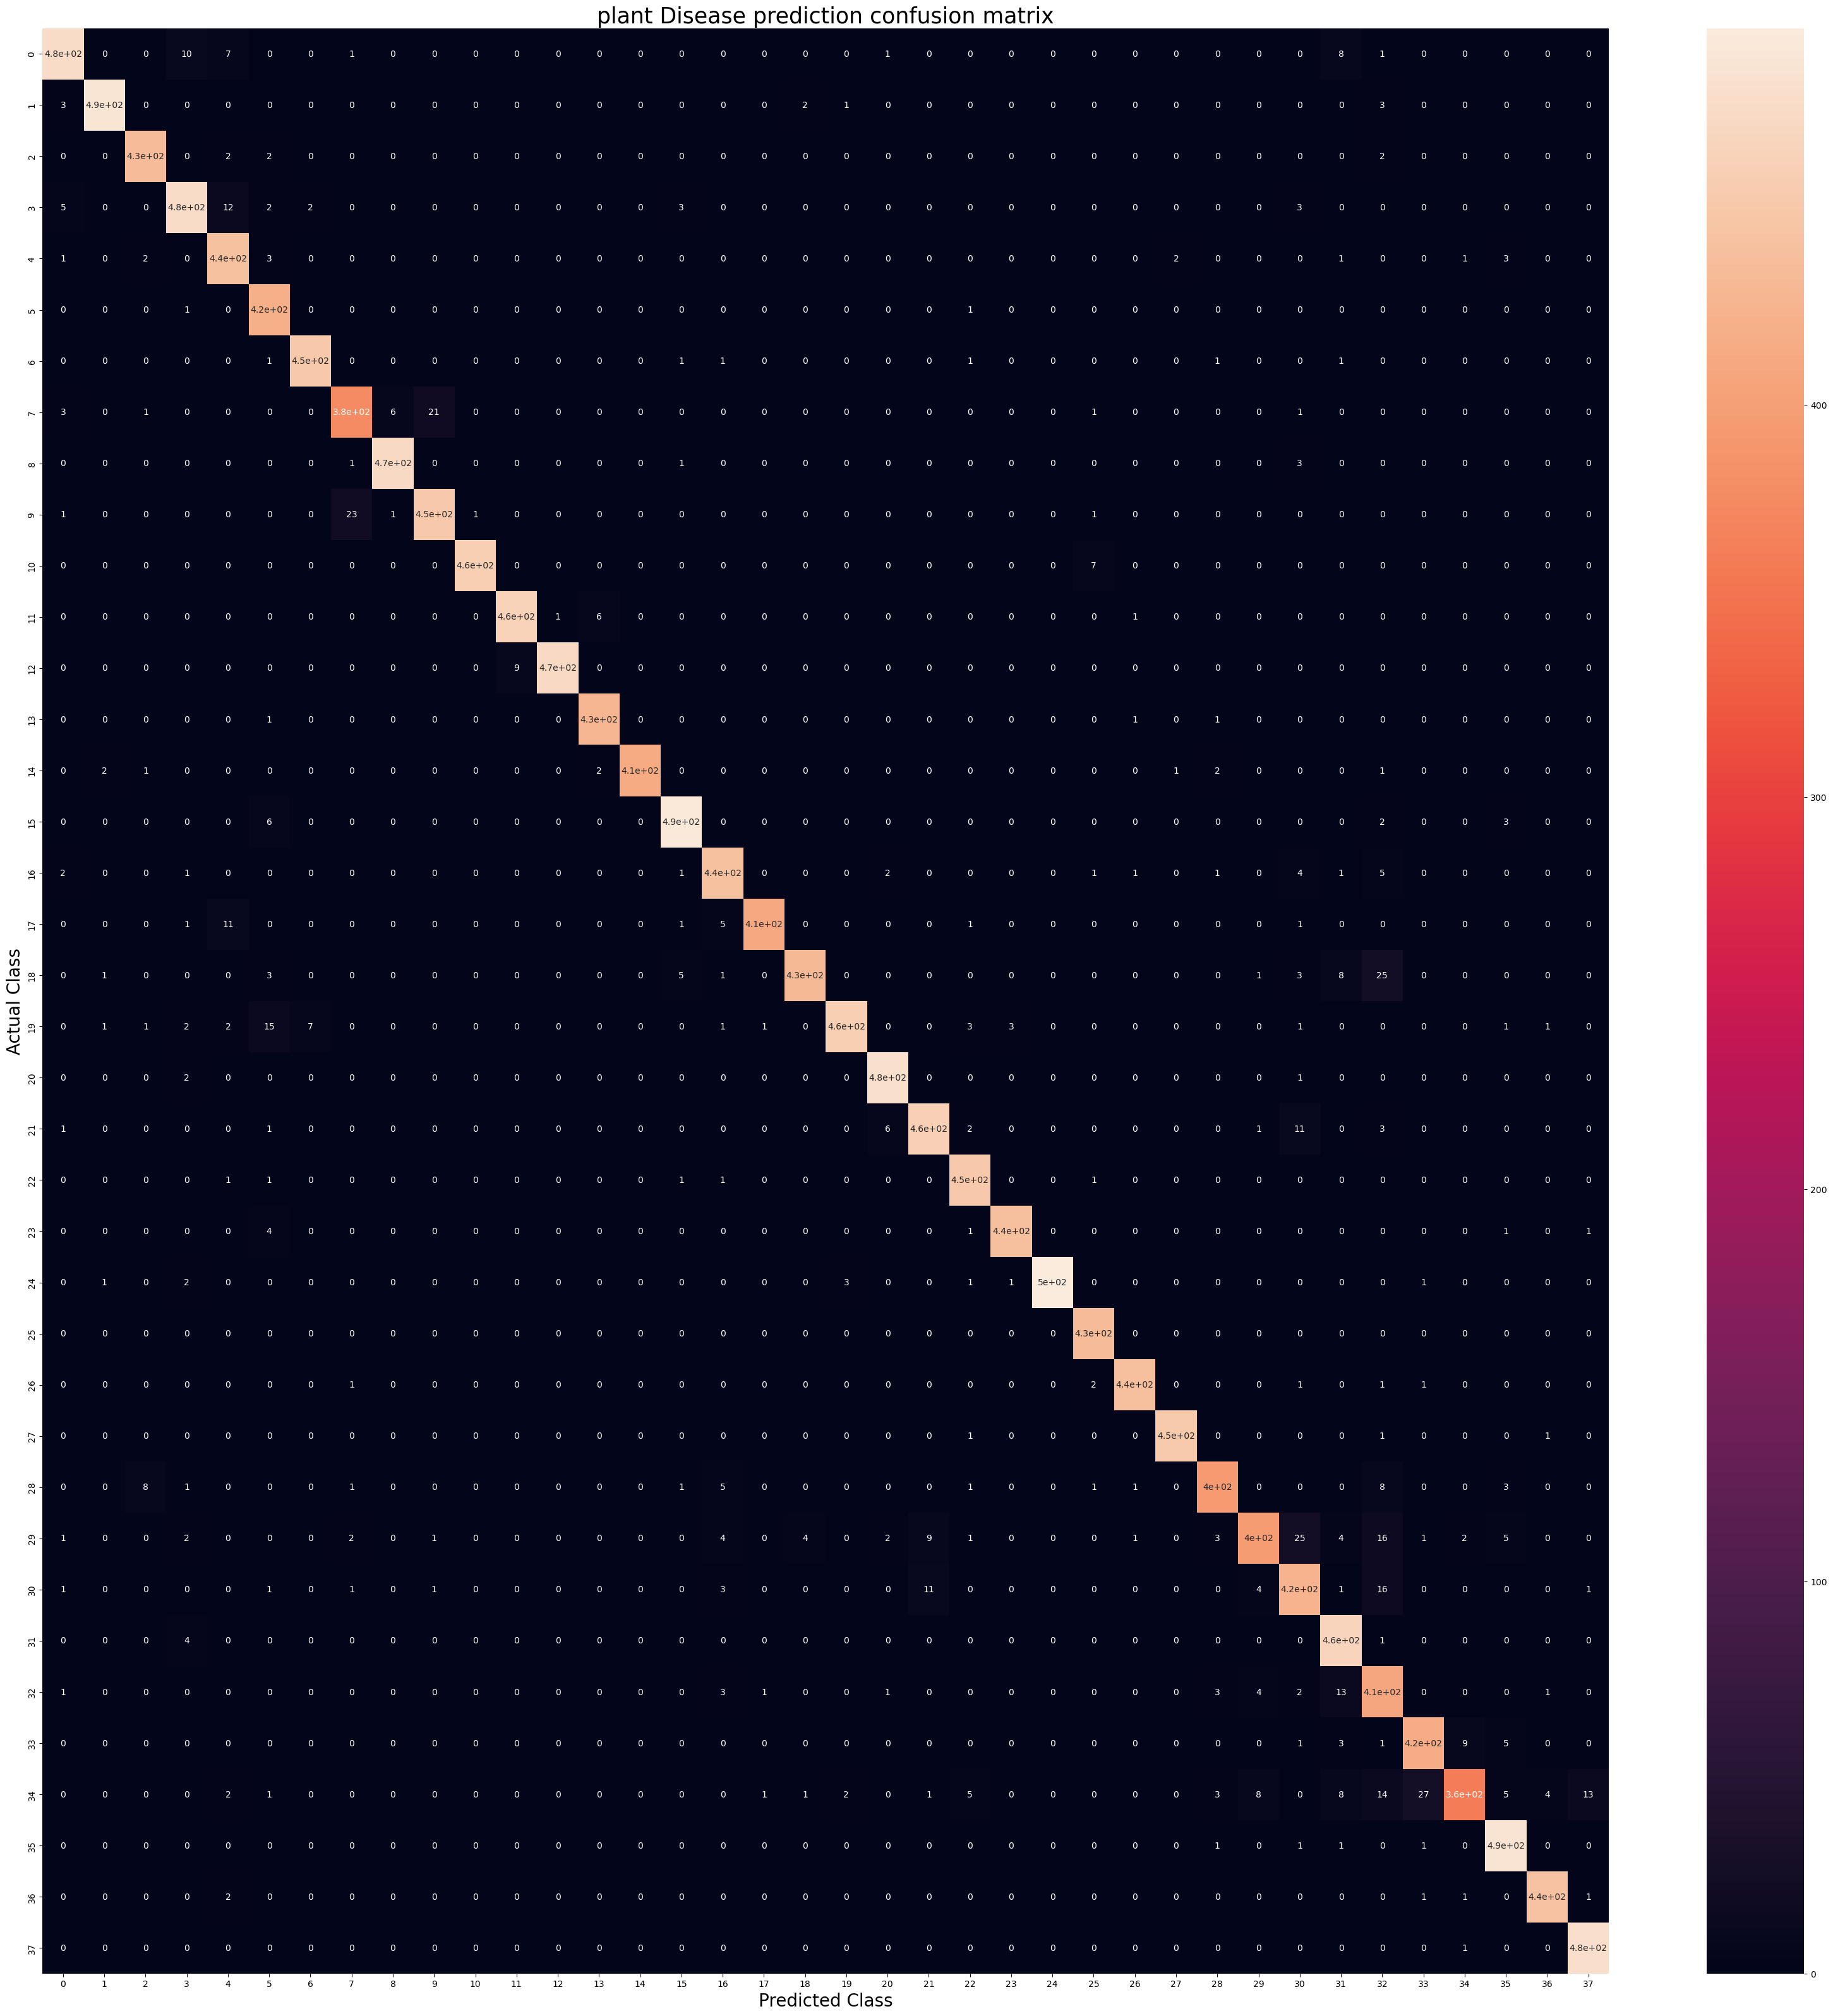

In [47]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("plant Disease prediction confusion matrix",fontsize=25)
plt.show()